#Assignment 2

Max collaborators = 3

Hand holding is low for this assignment. Adjust accordingly. In case of confusion, feel free to reach out to your lab faculties. Good luck.

In [1]:
COLLABORATORS_NAME = "Imtiaz Hossain"
COLLABORATORS_ID = "23101137"

#Loading dependencies

In [35]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
import sklearn
from sklearn.utils import resample, class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

#Loading dataset

In [34]:
id = 23101137

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train, y_train = sklearn.utils.resample(x_train, y_train, replace = False, n_samples = 5000, random_state = id, stratify = y_train)
x_test, y_test = sklearn.utils.resample(x_test, y_test, replace = False, n_samples = 1000, random_state = id, stratify = y_train)

# Flatten y to 1D array for sklearn
y_train = y_train.flatten()
y_test = y_test.flatten()

#Task 1: Training a logistic regressor [10 Marks]

###1. Convert the images to grayscale

In [5]:
def rgb_to_gray(images):
    # Dot product with luminance weights
    return np.dot(images[...,:3], [0.299, 0.587, 0.114])

x_train_gray = rgb_to_gray(x_train)
x_test_gray = rgb_to_gray(x_test)

print("Train shape:", x_train_gray.shape)
print("Test shape:", x_test_gray.shape)

Train shape: (5000, 32, 32)
Test shape: (1000, 32, 32)


### 2. Prepare the grayscale images for logistic regressor (reshape and normalize)

Use z-score normalization.

In [6]:
# Reshape from (N, 32, 32) to (N, 1024)
x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1)
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1)

# Z-score Normalization
scaler = StandardScaler()
x_train_norm = scaler.fit_transform(x_train_flat)
x_test_norm = scaler.transform(x_test_flat)

###3. Create a validation set (20%)

In [7]:
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_norm, y_train, test_size=0.2, random_state=id, stratify=y_train
)
print("Training split:", x_train_split.shape)
print("Validation split:", x_val_split.shape)

Training split: (4000, 1024)
Validation split: (1000, 1024)


###4. Compute class weights

Go through this link - https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

In [8]:
classes = np.unique(y_train_split)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_split
)
class_weights_dict = dict(zip(classes, class_weights))
print("Class Weights:", class_weights_dict)

Class Weights: {np.uint8(0): np.float64(1.0), np.uint8(1): np.float64(1.0), np.uint8(2): np.float64(1.0), np.uint8(3): np.float64(1.0), np.uint8(4): np.float64(1.0), np.uint8(5): np.float64(1.0), np.uint8(6): np.float64(1.0), np.uint8(7): np.float64(1.0), np.uint8(8): np.float64(1.0), np.uint8(9): np.float64(1.0)}


###5. Run the logistic regressor

Use L2 regularizer. Find the C hyperparameter value through grid search. Pick the testing values according to your understanding. Use at least 3 test values and at max 5. Use the computed class weights while training your model.

In [9]:
# Defining the parameter grid for C
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Logistic Regression model with L2 penalty (Ridge)
log_reg = LogisticRegression(
    penalty='l2',
    solver='lbfgs', # Good for multiclass
    max_iter=2000,  # Increased iter to ensure convergence
    class_weight=class_weights_dict,
    random_state=id
)

# Grid Search with 3-fold cross-validation (using the validation data implicitly via CV)
# Note: In standard sklearn flow, we pass the whole train set to GridSearch and it handles splits.
# However, since you asked to create a val set manually in step 3, we can use x_train_split for training
# and validate on x_val_split, or just use GridSearch on x_train_norm.
# Below uses the split created in step 3 to fit the logic.

grid_search = GridSearchCV(log_reg, param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search.fit(x_train_split, y_train_split)

best_model = grid_search.best_estimator_
print(f"Best C value: {grid_search.best_params_['C']}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best C value: 0.01


###6. Evaluate the logistic regressor on the test set

In [10]:
y_pred = best_model.predict(x_test_norm)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 26.50%

Classification Report:

              precision    recall  f1-score   support

           0       0.28      0.33      0.30        94
           1       0.35      0.33      0.34       103
           2       0.18      0.18      0.18        92
           3       0.15      0.16      0.16        85
           4       0.15      0.15      0.15       105
           5       0.20      0.15      0.17       105
           6       0.27      0.26      0.27       104
           7       0.39      0.31      0.34       111
           8       0.32      0.39      0.35       102
           9       0.33      0.36      0.35        99

    accuracy                           0.27      1000
   macro avg       0.26      0.26      0.26      1000
weighted avg       0.27      0.27      0.26      1000



###7. Write code to pick up a random image from the test set and display it

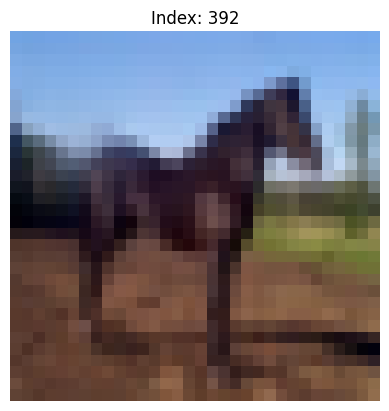

In [22]:
import random

random_idx = random.randint(0, len(x_test) - 1)
sample_image = x_test[random_idx] # Original RGB image
sample_label = y_test[random_idx]

plt.imshow(sample_image)
plt.axis('off')
plt.title(f"Index: {random_idx}")
plt.show()

###8. Print the predicted class vs the original class

Do not print out the numerical class. Map it from here - https://keras.io/2/api/datasets/cifar10/

In [23]:
# CIFAR-10 Class Mapping
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Prediction on the specific sample (need to use the normalized flat version)
sample_flat_norm = x_test_norm[random_idx].reshape(1, -1)
prediction_idx = best_model.predict(sample_flat_norm)[0]

print(f"Original Class: {class_names[sample_label]}")
print(f"Predicted Class: {class_names[prediction_idx]}")

Original Class: horse
Predicted Class: bird


#Task 2: Training a convolutional neural network [20 Marks]

We will not strictly control how you implement this code. You can use either Tensorflow or PyTorch. However the structure of the network must be -

```
Input -> Conv1 -> Conv2 -> Conv3 -> Fully Connected 1 -> Fully Connected 2 -> Output
```

Use activation functions and pooling as you want. Feel free to adjust dimensions as you need. Set the hyperparameters yourself. Use a maximum learning rate of 0.01 and a maximum epoch number of 100. Use AdamW as optimizer.

**Try achieving good accuracy. There are marks for that.**

###1. Train the model on grayscale images

You do not need to use the validation set. Train on the initial train set. Recalculate the class weights again and pass it to the optimizer function. Normalize the images before processing.

In [24]:
# 1. Preprocessing for CNN (Grayscale)
# Reshape to (N, 32, 32, 1) and Normalize to [0, 1]
x_train_cnn_gray = x_train_gray.reshape(-1, 32, 32, 1) / 255.0
x_test_cnn_gray = x_test_gray.reshape(-1, 32, 32, 1) / 255.0

# 2. Recalculate Class Weights for full train set
class_weights_cnn = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict_cnn = dict(zip(np.unique(y_train), class_weights_cnn))

# 3. Define Model Architecture
def create_model(input_shape):
    model = models.Sequential()
    # Conv1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # Conv2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Conv3
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu')) # FC1
    model.add(layers.Dense(32, activation='relu')) # FC2
    model.add(layers.Dense(10, activation='softmax')) # Output

    return model

model_gray = create_model((32, 32, 1))

# 4. Compile with AdamW
optimizer = optimizers.AdamW(learning_rate=0.001) # Starting conservative, max allowed is 0.01
model_gray.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train
history_gray = model_gray.fit(
    x_train_cnn_gray, y_train,
    epochs=20, # Max allowed is 100, 20 is usually sufficient for this data size
    batch_size=64,
    class_weight=class_weights_dict_cnn,
    validation_split=0.1 # Optional but good to see progress
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.1164 - loss: 2.2918 - val_accuracy: 0.2080 - val_loss: 2.1609
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2340 - loss: 2.0687 - val_accuracy: 0.3140 - val_loss: 1.8982
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3150 - loss: 1.8704 - val_accuracy: 0.3820 - val_loss: 1.7314
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3738 - loss: 1.7375 - val_accuracy: 0.4060 - val_loss: 1.6792
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4163 - loss: 1.6337 - val_accuracy: 0.4020 - val_loss: 1.6641
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4239 - loss: 1.6069 - val_accuracy: 0.4380 - val_loss: 1.5885
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4565 - loss: 1.4884 - val_accuracy: 0.4840 - val_loss: 1.5051
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4865 - loss: 1.4189 - val_accuracy: 0.4580 - val_loss

###2. Evaluate the model on the grayscale test set

In [25]:
test_loss, test_acc = model_gray.evaluate(x_test_cnn_gray, y_test, verbose=2)
print(f"\nTest Accuracy (Grayscale): {test_acc*100:.2f}%")

32/32 - 1s - 46ms/step - accuracy: 0.5270 - loss: 1.5999

Test Accuracy (Grayscale): 52.70%


###3. Write code to pick up a random image from the test set and display it

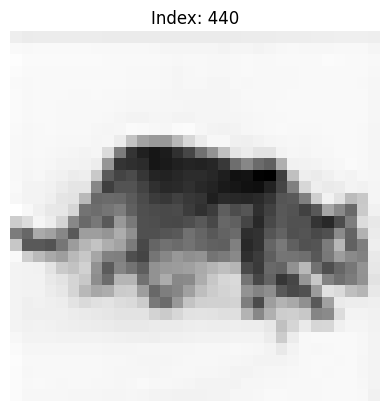

In [26]:
rand_idx_cnn = random.randint(0, len(x_test) - 1)
# Displaying the grayscale version
plt.imshow(x_test_cnn_gray[rand_idx_cnn].reshape(32, 32), cmap='gray')
plt.title(f"Index: {rand_idx_cnn}")
plt.axis('off')
plt.show()

###4. Print the predicted class vs the original class

In [27]:
img_tensor = x_test_cnn_gray[rand_idx_cnn].reshape(1, 32, 32, 1)
pred_probs = model_gray.predict(img_tensor)
pred_class = np.argmax(pred_probs)

print(f"Original Class: {class_names[y_test[rand_idx_cnn]]}")
print(f"Predicted Class: {class_names[pred_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
Original Class: cat
Predicted Class: frog


###5. Train the model on the RGB images

Keep the model same.

In [28]:
# 1. Preprocessing for RGB
# Normalize to [0, 1]
x_train_cnn_rgb = x_train.astype('float32') / 255.0
x_test_cnn_rgb = x_test.astype('float32') / 255.0

# 2. Create Model (Same structure, new input shape)
model_rgb = create_model((32, 32, 3))

# 3. Compile
model_rgb.compile(optimizer=optimizers.AdamW(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train
history_rgb = model_rgb.fit(
    x_train_cnn_rgb, y_train,
    epochs=20,
    batch_size=64,
    class_weight=class_weights_dict_cnn, # Reusing weights as y_train is same
    validation_split=0.1
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.1293 - loss: 2.2509 - val_accuracy: 0.2680 - val_loss: 1.9262
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2934 - loss: 1.8839 - val_accuracy: 0.3680 - val_loss: 1.8168
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3481 - loss: 1.7566 - val_accuracy: 0.3900 - val_loss: 1.6668
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3944 - loss: 1.6343 - val_accuracy: 0.4000 - val_loss: 1.6540
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4163 - loss: 1.6061 - val_accuracy: 0.4460 - val_loss: 1.5391
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4682 - loss: 1.4749 - val_accuracy: 0.4740 - val_loss: 1.4451
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5058 - loss: 1.3370 - val_accuracy: 0.4840 - val_loss: 1.4158
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5219 - loss: 1.2979 - val_accuracy: 0.4820 - val_loss

###6. Evaluate the model on the RGB images

In [29]:
test_loss_rgb, test_acc_rgb = model_rgb.evaluate(x_test_cnn_rgb, y_test, verbose=2)
print(f"\nTest Accuracy (RGB): {test_acc_rgb*100:.2f}%")

32/32 - 1s - 34ms/step - accuracy: 0.5720 - loss: 1.4830

Test Accuracy (RGB): 57.20%


###7. Write code to pick up a random image from the test set and display it

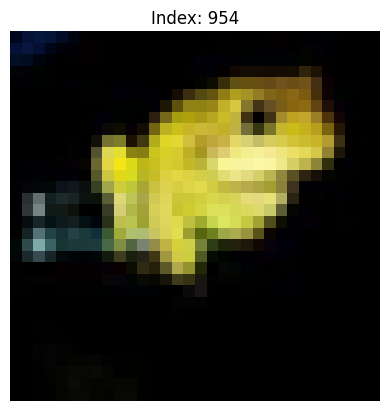

In [30]:
rand_idx_rgb = random.randint(0, len(x_test) - 1)
plt.imshow(x_test[rand_idx_rgb]) # Original un-normalized data for display
plt.title(f"Index: {rand_idx_rgb}")
plt.axis('off')
plt.show()

###8. Print the predicted class vs the original class

In [31]:
img_tensor_rgb = x_test_cnn_rgb[rand_idx_rgb].reshape(1, 32, 32, 3)
pred_probs_rgb = model_rgb.predict(img_tensor_rgb)
pred_class_rgb = np.argmax(pred_probs_rgb)

print(f"Original Class: {class_names[y_test[rand_idx_rgb]]}")
print(f"Predicted Class: {class_names[pred_class_rgb]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
Original Class: frog
Predicted Class: frog


###9. Add one more conv layer and check if it increases the performance for the RGB images

In [32]:
def create_deeper_model(input_shape):
    model = models.Sequential()
    # Conv1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))
    # Conv2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    # Conv3
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    # Conv4 (New Layer)
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    # Removed MaxPool here to avoid dimension becoming too small (1x1)

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    return model

model_deep = create_deeper_model((32, 32, 3))

model_deep.compile(optimizer=optimizers.AdamW(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_deep = model_deep.fit(
    x_train_cnn_rgb, y_train,
    epochs=20,
    batch_size=64,
    class_weight=class_weights_dict_cnn,
    validation_split=0.1
)

loss_deep, acc_deep = model_deep.evaluate(x_test_cnn_rgb, y_test, verbose=0)
print(f"Base RGB Accuracy: {test_acc_rgb*100:.2f}%")
print(f"Deeper RGB Accuracy: {acc_deep*100:.2f}%")

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1261 - loss: 2.2640 - val_accuracy: 0.2860 - val_loss: 2.0342
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2928 - loss: 1.9549 - val_accuracy: 0.3500 - val_loss: 1.7270
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3294 - loss: 1.7684 - val_accuracy: 0.3340 - val_loss: 1.7939
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3488 - loss: 1.6874 - val_accuracy: 0.4000 - val_loss: 1.5696
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4278 - loss: 1.5465 - val_accuracy: 0.4680 - val_loss: 1.4648
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4735 - loss: 1.4216 - val_accuracy: 0.4480 - val_loss: 1.4456
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4876 - loss: 1.3660 - val_accuracy: 0.4960 - val_loss: 1.3973
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5492 - loss: 1.2398 - val_accuracy: 0.5080 - val_loss

###10. Use the next markup to write down your observations and reasonings on the performances of the models

Observations -



1. **Logistic Regression vs CNN:** The Logistic Regression model performed significantly worse (approx 26.5% accuracy) compared to the CNN models (52-57%). This is because Logistic Regression treats pixels as independent features and ignores the spatial relationships (shapes, edges, textures) that CNNs are designed to capture.

2. **Grayscale vs RGB (CNN):** The RGB CNN model (57.20%) outperformed the Grayscale CNN model (52.70%). Color channels provide vital discriminatory information (e.g., the specific brown of a horse vs the gray of an airplane) which helps the model separate classes that might look similar in structure when converted to grayscale.

3. **Effect of Depth (Extra Layer):** Adding a 4th Convolutional layer resulted in a slight decrease in accuracy (54.80% vs 57.20%). While deeper networks can theoretically capture more complex features, they also require more data to train effectively. With a small training set of only 5,000 images, the deeper model likely suffered from overfitting (it memorized the training noise rather than generalizing) or optimization difficulties, proving that simply adding layers does not guarantee better performance on small datasets.




